In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Environment ready")

Environment ready


In [3]:
path = "../data/raw/medicare_provider_service_2024.csv"

df = pd.read_csv(path, low_memory=False)

print(df.shape)
df.head()

(9781673, 28)


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,Rndrng_Prvdr_Cntry,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,HCPCS_Cd,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9781673 entries, 0 to 9781672
Data columns (total 28 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   Rndrng_NPI                     int64  
 1   Rndrng_Prvdr_Last_Org_Name     object 
 2   Rndrng_Prvdr_First_Name        object 
 3   Rndrng_Prvdr_MI                object 
 4   Rndrng_Prvdr_Crdntls           object 
 5   Rndrng_Prvdr_Ent_Cd            object 
 6   Rndrng_Prvdr_St1               object 
 7   Rndrng_Prvdr_St2               object 
 8   Rndrng_Prvdr_City              object 
 9   Rndrng_Prvdr_State_Abrvtn      object 
 10  Rndrng_Prvdr_State_FIPS        object 
 11  Rndrng_Prvdr_Zip5              object 
 12  Rndrng_Prvdr_RUCA              float64
 13  Rndrng_Prvdr_RUCA_Desc         object 
 14  Rndrng_Prvdr_Cntry             object 
 15  Rndrng_Prvdr_Type              object 
 16  Rndrng_Prvdr_Mdcr_Prtcptg_Ind  object 
 17  HCPCS_Cd                       object 
 18  HC

In [5]:
df.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI',
       'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA',
       'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
       'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs',
       'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt'],
      dtype='object')

In [6]:
useful_cols = [
    "Rndrng_NPI",
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_Type",
    "Rndrng_Prvdr_Mdcr_Prtcptg_Ind",
    "HCPCS_Cd",
    "HCPCS_Desc",
    "HCPCS_Drug_Ind",
    "Place_Of_Srvc",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Bene_Day_Srvcs",
    "Avg_Sbmtd_Chrg",
    "Avg_Mdcr_Alowd_Amt",
    "Avg_Mdcr_Pymt_Amt",
    "Avg_Mdcr_Stdzd_Amt"
]

df_small = df[useful_cols].copy()

df_small.shape

(9781673, 15)

#### rename columns

In [7]:
df_small.columns = [
    "provider_npi",
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code",
    "hcpcs_description",
    "is_drug",
    "place_of_service",
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount"
]

df_small.head()

,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount
0,1003000126,MD,Internal Medicine,Y,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,MD,Internal Medicine,Y,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,MD,Internal Medicine,Y,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,MD,Internal Medicine,Y,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,MD,Internal Medicine,Y,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


In [8]:
missing = df_small.isna().sum().sort_values(ascending=False)

missing

provider_npi                        0
provider_state                      0
provider_type                       0
medicare_participating              0
hcpcs_code                          0
hcpcs_description                   0
is_drug                             0
place_of_service                    0
total_beneficiaries                 0
total_services                      0
total_beneficiary_day_services      0
avg_submitted_charge                0
avg_medicare_allowed_amount         0
avg_medicare_payment_amount         0
avg_medicare_standardized_amount    0
dtype: int64

#### check for duplicates

In [9]:
df_small.duplicated().sum()

np.int64(0)

In [10]:
df_small.describe()

,provider_npi,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount
count,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06
mean,1.499356e+09,8.498743e+01,2.818193e+02,1.372579e+02,4.307621e+02,1.063680e+02,8.300478e+01,8.249464e+01
std,2.877017e+08,1.312172e+03,6.307908e+03,2.181447e+03,1.521585e+03,3.329877e+02,2.656162e+02,2.671587e+02
min,1.003000e+09,1.100000e+01,4.400000e+00,1.100000e+01,3.508770e-05,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.245947e+09,1.700000e+01,2.100000e+01,2.000000e+01,7.328125e+01,2.548538e+01,1.965000e+01,1.947113e+01
50%,1.497941e+09,3.200000e+01,4.300000e+01,4.100000e+01,1.800000e+02,7.155108e+01,5.245652e+01,5.265500e+01
75%,1.740789e+09,7.200000e+01,1.190000e+02,1.060000e+02,3.670000e+02,1.211388e+02,9.091222e+01,9.077629e+01
max,1.993000e+09,8.967620e+05,6.486401e+06,1.835261e+06,9.999999e+04,5.396543e+04,4.299489e+04,4.299489e+04


In [11]:
df_small["charge_to_allowed_ratio"] = (
    df_small["avg_submitted_charge"] / df_small["avg_medicare_allowed_amount"]
)

df_small["payment_to_charge_ratio"] = (
    df_small["avg_medicare_payment_amount"] / df_small["avg_submitted_charge"]
)

df_small["payment_to_allowed_ratio"] = (
    df_small["avg_medicare_payment_amount"] / df_small["avg_medicare_allowed_amount"]
)

df_small["services_per_beneficiary"] = (
    df_small["total_services"] / df_small["total_beneficiaries"]
)

df_small.head()

,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary
0,1003000126,MD,Internal Medicine,Y,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389,3.596824,0.213901,0.769364,1.000000
1,1003000126,MD,Internal Medicine,Y,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133,2.787511,0.271670,0.757282,1.000000
2,1003000126,MD,Internal Medicine,Y,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365,4.602003,0.171302,0.788333,1.000000
3,1003000126,MD,Internal Medicine,Y,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250,2.553180,0.273086,0.697238,1.454545
4,1003000126,MD,Internal Medicine,Y,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857,7.167102,0.107485,0.770353,1.891892


In [18]:
engineered_cols = [
    "charge_to_allowed_ratio",
    "payment_to_charge_ratio",
    "payment_to_allowed_ratio",
    "services_per_beneficiary"
]

df_small = df_small.dropna(subset=engineered_cols)

df_small[engineered_cols].isna().sum()

charge_to_allowed_ratio     0
payment_to_charge_ratio     0
payment_to_allowed_ratio    0
services_per_beneficiary    0
dtype: int64

#### Save Sample

In [19]:
sample_df = df_small.sample(n=100_000, random_state=42)

sample_df.to_csv("../data/processed/medicare_provider_service_sample_100k.csv", index=False)

sample_df.shape

(100000, 19)

In [20]:
sample_df.to_parquet("../data/processed/medicare_provider_service_sample_100k.parquet", index=False)

In [21]:
top_provider_types = (
    df_small.groupby("provider_type")["total_services"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_provider_types

provider_type
Clinical Laboratory                       304353832.8
Diagnostic Radiology                      205360764.4
Hematology-Oncology                       204641019.2
Physical Therapist in Private Practice    171134158.0
Rheumatology                              163784256.0
Nurse Practitioner                        163487674.7
Ophthalmology                             149374584.7
Internal Medicine                         140258389.5
Ambulance Service Provider                115159154.9
Family Practice                           100314968.9
Physician Assistant                        80317800.0
Orthopedic Surgery                         68465531.7
Cardiology                                 59631172.2
Neurology                                  58039787.1
Medical Oncology                           53822577.1
Dermatology                                49081997.5
Ambulatory Surgical Center                 48421423.0
Urology                                    45061771.9
Infectious Dis

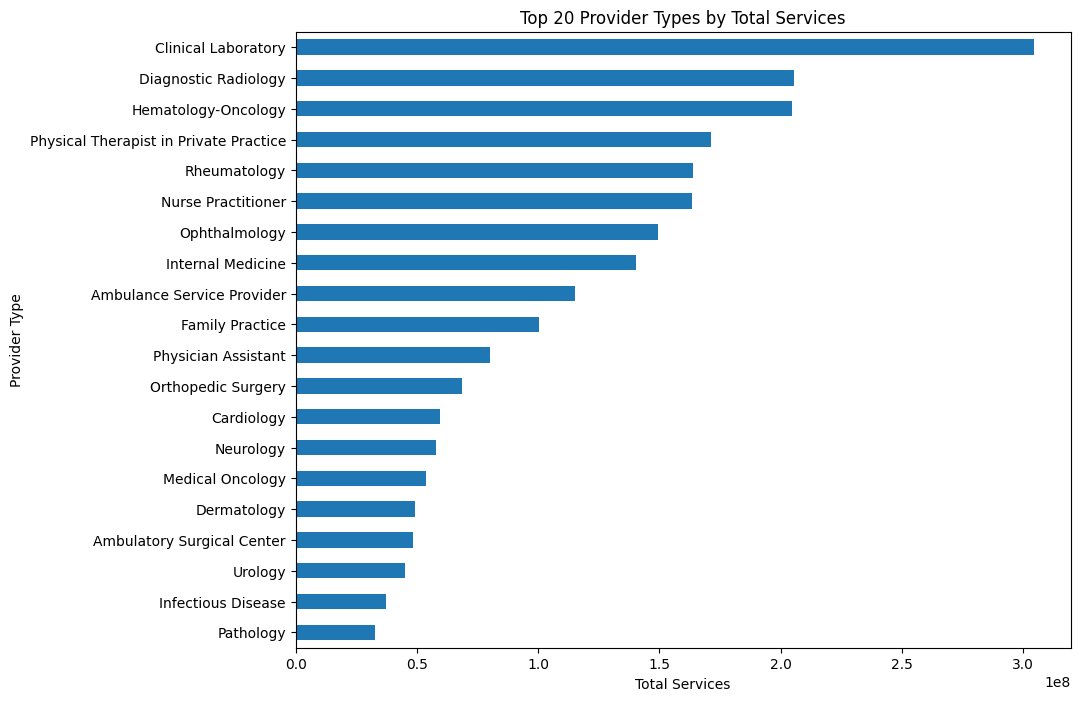

In [22]:
top_provider_types.sort_values().plot(kind="barh", figsize=(10, 8))

plt.title("Top 20 Provider Types by Total Services")
plt.xlabel("Total Services")
plt.ylabel("Provider Type")
plt.show()